# Tamura


In [ ]:
import numpy as np
import cv2
import networkx as nx
from skimage.feature import local_binary_pattern
from google.colab.patches import cv2_imshow
from skimage.feature import graycomatrix, graycoprops
import numpy as np

In [ ]:
# dilate mask and get inner and outer boundary of contour
def get_coord(mask, iterations):

  kernel = np.ones((3,3), np.uint8)

  # find dilated image
  dilated = cv2.dilate(mask, kernel, iterations=iterations)
  # cv2_imshow(dilated)

  # find the boundaries
  eroded= cv2.erode(dilated, kernel, iterations=1)
  final= dilated-eroded
  # cv2_imshow(final)

  contours, hierarchy = cv2.findContours(final.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
  # contours = contours[::-1]
  # hierarchy = hierarchy[::-1]

  # find inner and outer contours
  outer_contours = []
  inner_contours = []

  outer=[]
  inner=[]

  mx=-1
  for i in hierarchy[0]:
    mx= max(mx, i[3])

  for i, contour in enumerate(contours):
    #print(hierarchy[0][i][3])
    # Check the hierarchy to classify contours
    if hierarchy[0][i][3] == -1 and len(outer)==0:  # Outer contour (no parent)
      outer_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        outer.append([y,x])
    elif hierarchy[0][i][3] == mx:  # Inner contour (has a parent)
      inner_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        inner.append([y,x])

  # output_image = np.zeros_like(mask)
  # for p in outer:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)
  # for p in inner:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)

  # find all points which are white
  white = np.column_stack(np.where(dilated == 255)).tolist()

  for i in outer:
    i[0]= int(i[0])
    i[1]= int(i[1])
  for i in inner:
    i[0]= int(i[0])
    i[1]= int(i[1])

  return white, outer, inner


In [ ]:
def similarity_function(p, q,con1, con2, sigma_I=10, sigma_G=5, sigma_d=2):
    """Compute similarity weight between two pixels using intensity and Gabor features."""
    # intensity_diff = np.linalg.norm(np.array(p) - np.array(q))
    con_diff =np.linalg.norm(np.array(con1) - np.array(con2))
    weight = 1 / (1 + abs(int(con1) - int(con2)))
    spatial_diff = 1
    return weight
    # return (
    #     # np.exp(- (intensity_diff ** 2) / (2 * sigma_I ** 2)) *
    #     np.exp(- (con_diff ** 2) / (2 * sigma_G ** 2)) *
    #     np.exp(- (spatial_diff ** 2) / (2 * sigma_d ** 2))
    # )


# create custom weight function
def get_weight(img, gabor_features, lst1, lst2):
    """Computes edge weight based on intensity and Gabor texture features."""
    return similarity_function(img[lst1[0], lst1[1]], img[lst2[0], lst2[1]],
                               gabor_features["contrast"][lst1[0], lst1[1]], gabor_features["contrast"][lst2[0], lst2[1]])


def get_graph(img, node_map, gabor_features):
  G = nx.Graph()

  # Define 8-connectivity for neighboring pixels
  for x in range(height):
    for y in range(width):

      if node_map.get(str([x,y])) == None:
        continue

      if x < height - 1: # down node
        next= [x+1,y]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features ,[x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

      if y < width - 1: # right node
        next= [x,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x < height - 1 and y < width -1 : # down-right node
        next= [x+1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x > 0 and y < width-1: # top-right node
        next= [x-1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

# See graph adjacency list
# G.adj
  return G


In [ ]:
def get_cut(G):
  cut_value, partition = nx.minimum_cut(G, "source", "sink")
  reachable, non_reachable = partition
  cutset = set()
  for u, nbrs in ((n, G[n]) for n in reachable):
    cutset.update((u, v) for v in nbrs if v in non_reachable)

  return cutset


In [ ]:
def nearest_source(a, node_map):
  dx= [-1, -1, -1, 0, 0, 1, 1, 1]
  dy= [-1, 0, 1, -1, 1, -1, 0, 1]
  for k in range(8):
    x= a[0]+ dx[k]
    y= a[1]+ dy[k]
    if node_map.get(str([x,y])) != None and node_map[str([x,y])]=="source":
      return (x,y)

  return None

def get_nextmask(cutset, node_map):
  contour_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
  next_mask = np.zeros_like(img)

  for [a,b] in cutset:
    if a == "source":
      x,y= nearest_source(b, node_map)
      next_mask[x,y]=255
      contour_image[x,y]= (0, 255, 0)
    else:
      next_mask[a[0], a[1]]=255
      contour_image[a[0],a[1]]= (0, 255, 0)

  return next_mask,contour_image


300 300


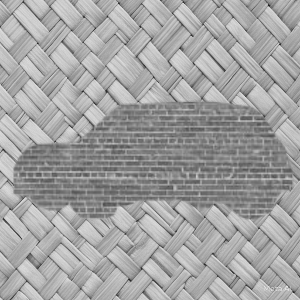

In [ ]:
# Load the image
img = cv2.imread('/content/car_texture.jpg', 0)  #load image in grayscale
img= cv2.resize(img, (300, 300))
(height,width)= img.shape
print(height, width)
cv2_imshow(img)


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, maximum_filter, minimum_filter
from skimage.color import rgb2gray
import math

# def load_image(image_path):
#     """Load an image and convert to grayscale if needed."""
#     img = cv2.imread(image_path)
#     if img is None:
#         raise ValueError(f"Could not load image from {image_path}")
#     img= cv2.resize(img, (250, 180))
#     # Convert to grayscale if the image is color
#     if len(img.shape) == 3 and img.shape[2] == 3:
#         img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     else:
#         img_gray = img

#     return img, img_gray.astype(float)

def calculate_coarseness_map(image, k_max=3):
    """Calculate Tamura coarseness feature map of the same size as the input image."""
    h, w = image.shape
    coarseness_map = np.zeros((h, w), dtype=np.float32)

    # For each k (1 to k_max)
    for k in range(1, k_max + 1):
        # Size of the neighborhood
        window_size = 2**k

        # Calculate average over neighborhoods
        kernel = np.ones((window_size, window_size)) / (window_size * window_size)

        # Compute average in neighborhoods
        blurred = cv2.filter2D(image, -1, kernel)

        # Calculate absolute differences in horizontal and vertical directions
        h_diff = np.abs(np.roll(blurred, shift=-2**(k-1), axis=1) - np.roll(blurred, shift=2**(k-1), axis=1))
        v_diff = np.abs(np.roll(blurred, shift=-2**(k-1), axis=0) - np.roll(blurred, shift=2**(k-1), axis=0))

        # Pad the borders (which have invalid values due to rolling)
        pad_size = 2**(k-1)
        h_diff[:, :pad_size] = 0
        h_diff[:, -pad_size:] = 0
        v_diff[:pad_size, :] = 0
        v_diff[-pad_size:, :] = 0

        # For each pixel, select the best size
        max_diff = np.maximum(h_diff, v_diff)
        weighted_diff = max_diff * (2**k)  # Weight by the size

        # Update best size if current difference is greater
        coarseness_map = np.maximum(coarseness_map, weighted_diff)

    # Normalize
    if np.max(coarseness_map) > 0:
        coarseness_map = coarseness_map / np.max(coarseness_map)

    return coarseness_map

def calculate_contrast_map(image, window_size=7):
    """Calculate Tamura contrast feature map of the same size as the input image."""
    h, w = image.shape
    contrast_map = np.zeros((h, w), dtype=np.float32)

    # Pad image for window operations
    padded_image = np.pad(image, window_size//2, mode='reflect')

    # For each pixel, calculate contrast in its neighborhood
    for y in range(h):
        for x in range(w):
            # Extract neighborhood
            neighborhood = padded_image[y:y+window_size, x:x+window_size]

            # Calculate standard deviation and kurtosis in the neighborhood
            std_dev = np.std(neighborhood)

            # Calculate kurtosis (using Fisher's definition: normal distribution has kurtosis=0)
            mean = np.mean(neighborhood)
            n = neighborhood.size
            m4 = np.sum((neighborhood - mean)**4) / n
            m2 = np.sum((neighborhood - mean)**2) / n

            if m2 == 0:  # Avoid division by zero
                kurt = 0
            else:
                kurt = (m4 / (m2**2)) - 3  # Excess kurtosis

            # Formula for contrast
            alpha = 0.25
            contrast = std_dev / (1 + np.abs(kurt)**alpha)

            contrast_map[y, x] = contrast

    # Normalize
    if np.max(contrast_map) > 0:
        contrast_map = contrast_map / np.max(contrast_map)

    return contrast_map

def calculate_directionality_map(image, window_size=7):
    """Calculate Tamura directionality feature map of the same size as the input image."""
    h, w = image.shape
    directionality_map = np.zeros((h, w), dtype=np.float32)

    # Compute gradients using Sobel operator
    dx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    dy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute gradient magnitude and direction
    magnitude = np.sqrt(dx**2 + dy**2)
    direction = np.arctan2(dy, dx) * (180 / np.pi) % 180  # Convert to degrees (0-180)

    # Pad arrays for window operations
    padded_magnitude = np.pad(magnitude, window_size//2, mode='reflect')
    padded_direction = np.pad(direction, window_size//2, mode='reflect')

    # For each pixel, calculate directionality in its neighborhood
    for y in range(h):
        for x in range(w):
            # Extract neighborhood
            neigh_magnitude = padded_magnitude[y:y+window_size, x:x+window_size]
            neigh_direction = padded_direction[y:y+window_size, x:x+window_size]

            # Filter out weak edges
            threshold = 0.2 * np.max(neigh_magnitude)
            mask = neigh_magnitude > threshold

            if np.sum(mask) > 0:
                # Create histogram of directions
                hist, _ = np.histogram(neigh_direction[mask], bins=16, range=(0, 180))
                hist = hist / np.sum(hist)  # Normalize

                # Find peaks in the histogram
                peak_count = 0
                for i in range(16):
                    left = (i - 1) % 16
                    right = (i + 1) % 16
                    if hist[i] > hist[left] and hist[i] > hist[right]:
                        peak_count += 1

                # Directionality is high when there are few strong peaks
                if peak_count > 0:
                    directionality_map[y, x] = 1.0 / peak_count
                else:
                    directionality_map[y, x] = 0
            else:
                directionality_map[y, x] = 0

    # Normalize
    if np.max(directionality_map) > 0:
        directionality_map = directionality_map / np.max(directionality_map)

    return directionality_map


def extract_tamura_features_maps(img_gray):
    """Extract all Tamura feature maps from an image."""
    # Load the image

    print("Calculating contrast map...")
    contrast_map = calculate_contrast_map(img_gray)


    # Collect all feature maps in a dictionary
    feature_maps = {
        'contrast': contrast_map,
      }

    return img_gray, feature_maps

def visualize_feature_maps(img, feature_maps):
    """Visualize all Tamura feature maps."""
    # Determine number of subplots
    n_features = len(feature_maps)
    n_cols = 3
    n_rows = (n_features + 1) // n_cols + 1  # +1 for the original image

    plt.figure(figsize=(15, n_rows * 4))

    # Plot original image
    plt.subplot(n_rows, n_cols, 1)
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # Plot feature maps
    for i, (feature_name, feature_map) in enumerate(feature_maps.items(), start=2):
        plt.subplot(n_rows, n_cols, i)
        plt.imshow(feature_map, cmap='jet')
        plt.title(f'{feature_name.capitalize()} Map')
        plt.colorbar()
        plt.axis('off')

    plt.tight_layout()
    plt.show()

try:
  # Extract feature maps
  img, feature_maps = extract_tamura_features_maps(img)

  # Print shape information
  print("\nFeature Map Shapes:")
  for feature_name, feature_map in feature_maps.items():
    print(f"{feature_name}: {feature_map.shape}")

except Exception as e:
  print(f"Error: {e}")

Calculating contrast map...

Feature Map Shapes:
contrast: (300, 300)


In [ ]:
def normalize_to_uint8(feature_map):
    """
    Convert a feature map to uint8 format with values ranging from 0 to 255.

    Args:
        feature_map: The input feature map (any range)

    Returns:
        Normalized feature map as uint8 with values from 0 to 255
    """
    # Handle the case where all values are the same
    if np.max(feature_map) == np.min(feature_map):
        return np.zeros_like(feature_map, dtype=np.uint8)

    # Normalize to 0-1 range
    normalized = (feature_map - np.min(feature_map)) / (np.max(feature_map) - np.min(feature_map))

    # Convert to 0-255 range and uint8 type
    uint8_map = (normalized * 255).astype(np.uint8)

    return uint8_map

In [ ]:
feature_maps["contrast"]= normalize_to_uint8(feature_maps["contrast"])

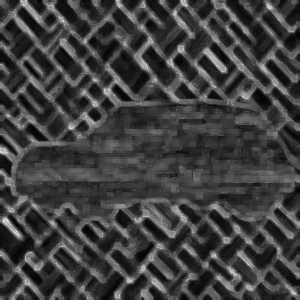

In [ ]:
cv2_imshow(feature_maps["contrast"])


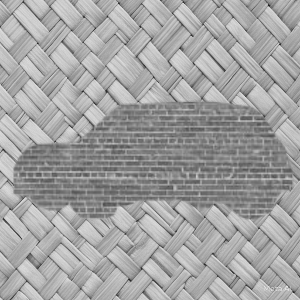

In [ ]:
cv2_imshow(img)

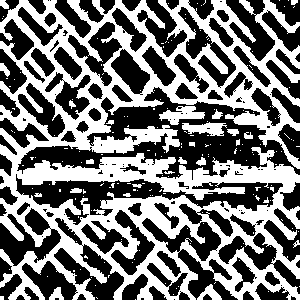

In [ ]:
p= feature_maps["contrast"]
_, binary_thresh = cv2.threshold(p,60, 255, cv2.THRESH_BINARY)
cv2_imshow(binary_thresh)


#feature_maps["contrast"]= binary_thresh

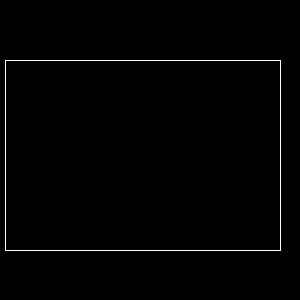

In [ ]:
# Initial binary mask (user-provided or from an edge detector)
mask = np.zeros_like(img)
#mushroom - cv2.circle(mask,(width//2, height//2),60, 255, 1)
mask= cv2.rectangle(mask, (5,60), (280,250), 255, 1)
cv2_imshow(mask)

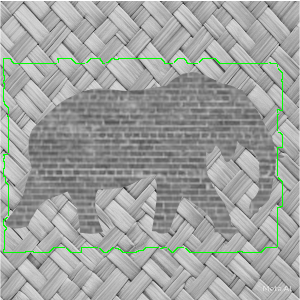

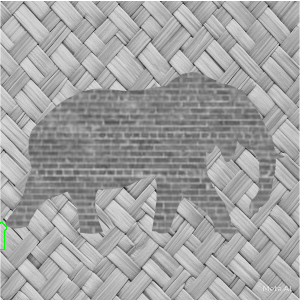

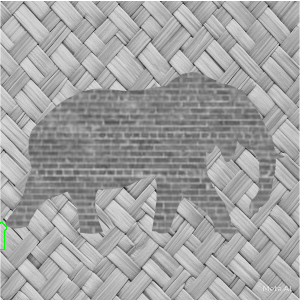

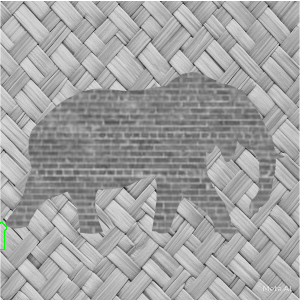

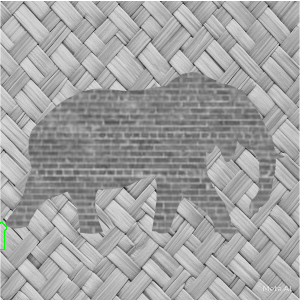

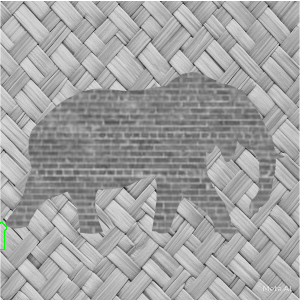

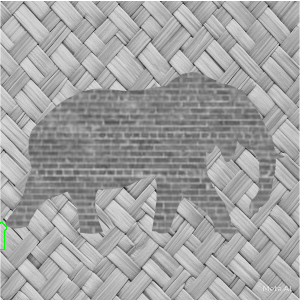

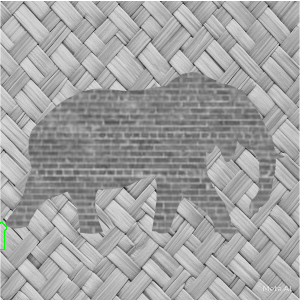

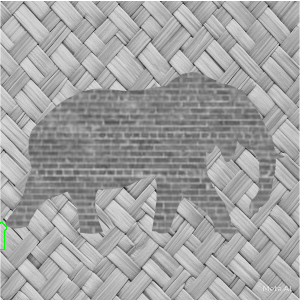

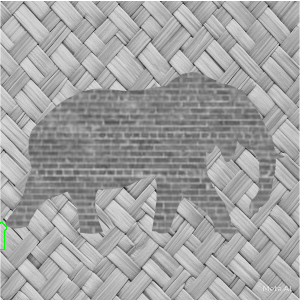

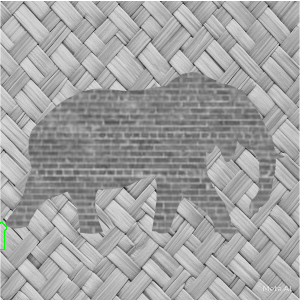

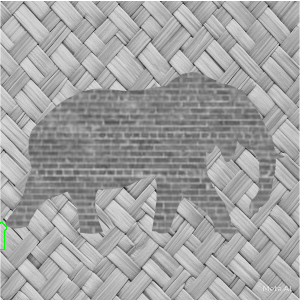

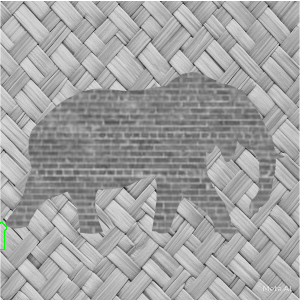

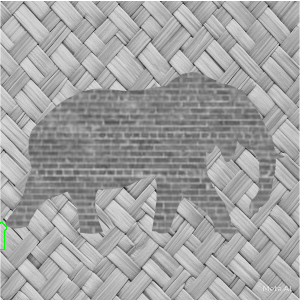

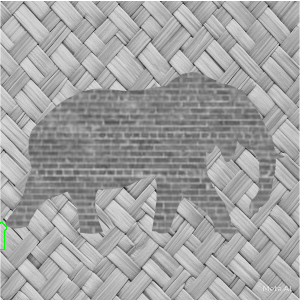

In [ ]:
for i in range(15):
  allnodes,sink,source= get_coord(mask, 3)
  node_map={}
  for node in allnodes:
    node_map[str(node)]= (node[0], node[1])

  for node in source:
    node_map[str(node)]= "source"

  for node in sink:
    node_map[str(node)]= "sink"

  G= get_graph(img, node_map, feature_maps)
  cutset= get_cut(G)
  mask,contour_image= get_nextmask(cutset, node_map)
  cv2_imshow(contour_image)

cv2.waitKey(0)
cv2.destroyAllWindows()